In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

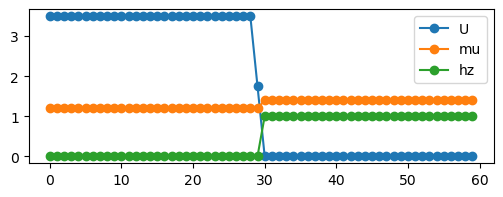

In [2]:
widthS = 30
widthF = 30

X, Y = widthS+widthF, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:] = muF

h0 = 1 * t
h = np.zeros_like(mu)
h[widthS:] = h0

U0 = 3.5 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2
# U=None

V0 = None

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=None,
                F_init=[0.1, -0.1, 0.1j, 0.1j],
                hz=h, F0_init=0.1)

In [4]:
bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.2586065795035302
Relative error: 30858979189.332188
Average old: (0.05+0j)
Average: (0.07280465139987104+0j)
F_xplus:
Absolute error: 0.13795710868272243
Relative error: 137957108682.7224
Average old: 0j
Average: (-0.01285399836855445+0j)
F_xmin:
Absolute error: 0.1357535979026617
Relative error: 135753597902.6617
Average old: 0j
Average: (-0.011657127870704949+0j)
F_yplus:
Absolute error: 0.1469481254344501
Relative error: 146948125434.4501
Average old: 0j
Average: (-0.013130066811318055-2.271385887695175e-17j)
F_ymin:
Absolute error: 0.1469481254344501
Relative error: 146948125434.4501
Average old: 0j
Average: (-0.013130066811318055+2.271385887695175e-17j)
Fuu_xplus:
Absolute error: 3.1732633027889935e-17
Relative error: 3.1732633027889934e-05
Average old: 0j
Average: (-6.933755347368793e-19+0j)
Fuu_xmin:
Absolute error: 3.1434190335515495e-17
Relative error: 3.14341903355155e-05
Average old: 0j
Average: (6.490909171336695e-19+0j)
Fuu_yplus:
Absolute error: 6.14

In [5]:
F, Fuu, Fdd = H.get_correlations()


T/t=0.001, hz/t=1


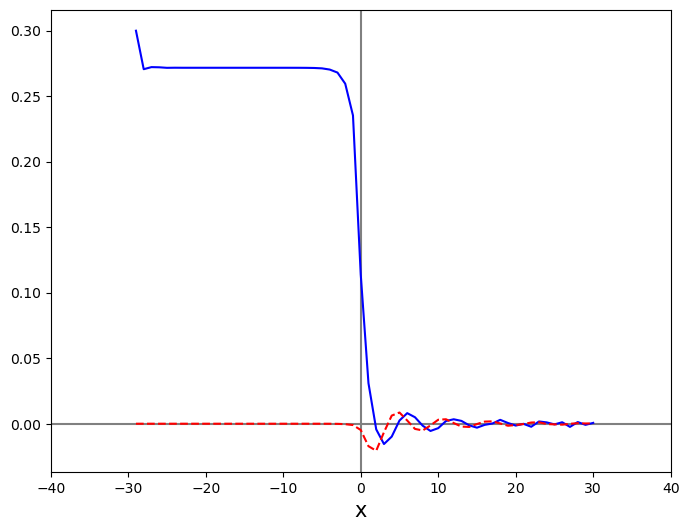

In [6]:
x = np.arange(-widthS, widthF) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')

axs.plot(x, np.real(H.F0), label=r"$\uparrow\downarrow -\downarrow\uparrow$", color='blue')
axs.plot(x, np.real(F.px), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='red')

axs.set_xlabel("x", fontsize=15)
axs.set_xlim(-40, 40)
plt.show()

C:\Users\emoeu\AppData\Local\Temp\ipykernel_30380\3012111224.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


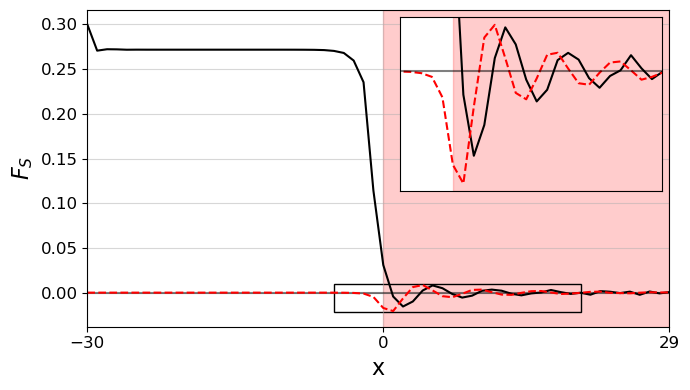

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

plt.figure(figsize=(7, 4))
ax = plt.gca()

x = np.arange(-widthS, widthF)
# Main plot
plt.axhline(0, color='black', alpha=0.5)
ln_nm, = ax.plot(x,np.real(H.F0), color='black')
ln_fm, = ax.plot(x,np.real(F.px), color='red', linestyle='--')

# ax.axvspan(x[0], 0, color='blue', alpha=0.2)
ax.axvspan(0, x[-1], color='red', alpha=0.2)

square = Rectangle((-5, -0.022), 25, 0.032, edgecolor='black', facecolor='none', linewidth=1)
ax.add_patch(square)

ax.set_xticks([-30,0,29])
ax.grid(True, alpha=0.5)
ax.set_xlabel(r"x", fontsize=16)
ax.set_ylabel(r"$F_{S}$", fontsize=16)
ax.tick_params(labelsize=12)
ax.set_xlim(-30, 29)

axins = inset_axes(ax, width="45%", height="55%", loc="upper right")

axins.axvspan(0, widthF, color='red', alpha=0.2)
axins.plot(x,np.real(H.F0), color='black')
axins.plot(x,np.real(F.px), color='red', linestyle='--')

axins.set_xlim(-5, 20)
axins.set_ylim(-0.022, 0.01)
axins.axhline(0, color='black', alpha=0.5)
axins.set_xticks([])
axins.set_yticks([])
axins.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/corr.svg', bbox_inches='tight')


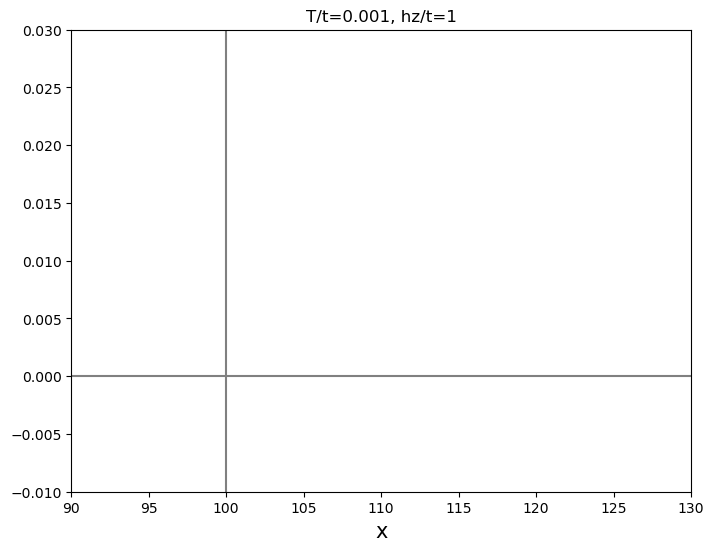

In [8]:
x = np.arange(1, widthS + widthF + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(100, color='gray')

axs.plot(x, np.real(H.F0), label=r"$\uparrow\downarrow -\downarrow\uparrow$", color='blue')
axs.plot(x, np.real(F.px), "--", label=r"$\uparrow\downarrow +\downarrow\uparrow$", color='red')

axs.set_xlabel("x", fontsize=15)
axs.set_ylim(-0.01, 0.03)
axs.set_xlim(90, 130)
plt.show()

In [36]:
print(np.sin(np.pi/2))

hmag_arr = np.linspace(0.2, 2, 18)
print(len(hmag_arr))

1.0
18
